In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from mpl_toolkits.mplot3d import Axes3D





In [7]:
data=pd.read_csv("StudentPerformanceFactors.csv")
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [8]:
print(data.head())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

In [10]:

print("\nMissing Values")
print(data.isnull().sum())


Missing Values
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [12]:

data.dropna(inplace=True)

In [14]:
data.drop_duplicates(inplace=True)

In [15]:

print("\nDataset Shape :", data.shape)


Dataset Shape : (6378, 20)


In [8]:

le = LabelEncoder()

data["Hours_Studied"] = le.fit_transform(
    data["Hours_Studied"]
)

In [10]:

X = data[["Sleep_Hours", "Hours_Studied"]]
y = data["Exam_Score"]

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

     

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:

y_pred = model.predict(X_test)

In [14]:

r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 50)
print("MODEL VALIDATION")
print("=" * 50)

print("R2 Score :", round(r2, 4))


MODEL VALIDATION
R2 Score : 0.2292


In [15]:

print("\nIntercept")
print(round(model.intercept_, 2))

print("\nCoefficients")

for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", round(coef, 2))


Intercept
62.42

Coefficients
Sleep_Hours : -0.09
Hours_Studied : 0.29


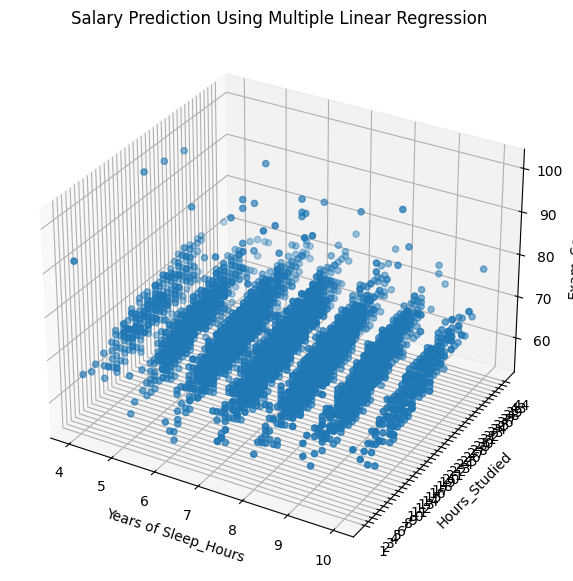

In [19]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    data["Sleep_Hours"],
    data["Hours_Studied"],
    data["Exam_Score"]
)

ax.set_xlabel("Years of Sleep_Hours")
ax.set_ylabel("Hours_Studied")
ax.set_zlabel("Exam_Score")

Hours_Studied_values = sorted(
    data["Hours_Studied"].unique()
)

education_names = le.inverse_transform(
    Hours_Studied_values 
)

ax.set_yticks(Hours_Studied_values )
ax.set_yticklabels(education_names)

plt.title(
    "Salary Prediction Using Multiple Linear Regression"
)

plt.show()
     